# Real-world A/B analysis: Hillstrom email experiment

This notebook applies `bootstrapx.bootstrap_two_sample` to Kevin Hillstrom's public email experiment. The dataset contains 64,000 customers randomized between a men's email, a women's email, and no email. Outcomes were recorded after assignment: website visit, purchase conversion, and spend.

We predefine one contrast—**Womens E-Mail versus No E-Mail**—and estimate intention-to-treat effects. The original CSV is downloaded from the author's source, verified by SHA-256, and cached locally under `data/`. It is not redistributed with bootstrapx because the source does not state a formal redistribution license.

Source: [MineThatData E-Mail Analytics and Data Mining Challenge](https://blog.minethatdata.com/2008/03/minethatdata-e-mail-analytics-and-data.html).

## Setup

From a repository checkout, install the project and notebook dependencies before running:

```bash
python -m pip install -e ".[pandas]" matplotlib jupyter
```

The download happens only when this notebook is explicitly executed. Importing bootstrapx, running its tests, and building the documentation do not access the network.

In [1]:
from __future__ import annotations

import hashlib
from pathlib import Path
from urllib.request import Request, urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from bootstrapx import bootstrap_two_sample

DATA_URL = (
    "http://www.minethatdata.com/"
    "Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv"
)
EXPECTED_SHA256 = "0e5893329d8b93cefecc571777672028290ab69865718020c78c7284f291aece"


def repository_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "bootstrapx").exists():
            return candidate
    raise RuntimeError("Run this notebook from the bootstrapx repository checkout.")


def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def fetch_hillstrom(path: Path) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    if not path.exists():
        temporary = path.with_suffix(".tmp")
        request = Request(DATA_URL, headers={"User-Agent": "bootstrapx-example/0.5"})
        try:
            with urlopen(request, timeout=60) as response, temporary.open("wb") as output:
                while chunk := response.read(1024 * 1024):
                    output.write(chunk)
            if sha256(temporary) != EXPECTED_SHA256:
                temporary.unlink(missing_ok=True)
                raise RuntimeError("Downloaded Hillstrom CSV failed its SHA-256 check.")
            temporary.replace(path)
        except Exception:
            temporary.unlink(missing_ok=True)
            raise

    if sha256(path) != EXPECTED_SHA256:
        raise RuntimeError(
            f"Cached file {path} has an unexpected checksum. Delete it and download again."
        )
    return path


data_path = fetch_hillstrom(repository_root() / "data" / "hillstrom.csv")
print("Using verified data: data/hillstrom.csv")

Using verified data: data/hillstrom.csv


## Validate the experiment data

Validation catches a changed upstream file, unexpected columns, missing outcomes, or altered assignment labels before analysis. Each row is one randomized customer, so ordinary independent resampling is appropriate for this contrast.

In [2]:
data = pd.read_csv(data_path)
expected_columns = {
    "recency", "history_segment", "history", "mens", "womens",
    "zip_code", "newbie", "channel", "segment", "visit",
    "conversion", "spend",
}
expected_segments = {"Mens E-Mail", "Womens E-Mail", "No E-Mail"}

assert data.shape == (64_000, 12)
assert set(data.columns) == expected_columns
assert set(data["segment"].unique()) == expected_segments
assert not data[["segment", "visit", "conversion", "spend"]].isna().any().any()
assert data["visit"].isin([0, 1]).all()
assert data["conversion"].isin([0, 1]).all()
assert data["spend"].ge(0).all()

group_summary = data.groupby("segment", observed=True).agg(
    customers=("segment", "size"),
    visit_rate=("visit", "mean"),
    conversion_rate=("conversion", "mean"),
    spend_per_customer=("spend", "mean"),
)
group_summary

,customers,visit_rate,conversion_rate,spend_per_customer
segment,,,,
Mens E-Mail,21307,0.182757,0.012531,1.422617
No E-Mail,21306,0.106167,0.005726,0.652789
Womens E-Mail,21387,0.151400,0.008837,1.077202


## Estimate treatment effects

We keep all assigned customers—including non-buyers with zero spend. Filtering to purchasers would condition on a post-treatment outcome and change the estimand.

The comparison uses 4,999 resamples, a fixed seed, and BCa intervals. Absolute effects are the primary results. Relative conversion lift is included as a secondary interpretation and is naturally less stable because the control conversion rate is small.

In [3]:
control = data.loc[data["segment"] == "No E-Mail"]
treatment = data.loc[data["segment"] == "Womens E-Mail"]


def compare(metric: str, effect: str, label: str, unit: str):
    result = bootstrap_two_sample(
        control[metric].to_numpy(dtype=float),
        treatment[metric].to_numpy(dtype=float),
        np.mean,
        effect=effect,
        method="bca",
        n_resamples=4_999,
        random_state=42,
    )
    return result, {
        "outcome": label,
        "unit": unit,
        "control": result.control_estimate,
        "treatment": result.treatment_estimate,
        "effect": result.estimate,
        "ci_low": result.confidence_interval.low,
        "ci_high": result.confidence_interval.high,
    }


analyses = [
    compare("visit", "difference", "Visit-rate difference", "percentage points"),
    compare(
        "conversion", "difference", "Conversion-rate difference", "percentage points"
    ),
    compare("conversion", "relative_lift", "Relative conversion lift", "percent"),
    compare("spend", "difference", "Spend per assigned customer", "USD/customer"),
]

results = pd.DataFrame([row for _, row in analyses]).set_index("outcome")
results

,unit,control,treatment,effect,ci_low,ci_high
outcome,,,,,,
Visit-rate difference,percentage points,0.106167,0.151400,0.045233,0.038865,0.051509
Conversion-rate difference,percentage points,0.005726,0.008837,0.003111,0.001519,0.004749
Relative conversion lift,percent,0.005726,0.008837,0.543313,0.236199,0.944987
Spend per assigned customer,USD/customer,0.652789,1.077202,0.424412,0.176435,0.683191


## Present effects in business units

In [4]:
display_table = results.copy()
rate_rows = ["Visit-rate difference", "Conversion-rate difference"]
display_table.loc[rate_rows, ["control", "treatment", "effect", "ci_low", "ci_high"]] *= 100
display_table.loc["Relative conversion lift", ["control", "treatment", "effect", "ci_low", "ci_high"]] *= 100
display_table.round(3)

,unit,control,treatment,effect,ci_low,ci_high
outcome,,,,,,
Visit-rate difference,percentage points,10.617,15.140,4.523,3.887,5.151
Conversion-rate difference,percentage points,0.573,0.884,0.311,0.152,0.475
Relative conversion lift,percent,0.573,0.884,54.331,23.620,94.499
Spend per assigned customer,USD/customer,0.653,1.077,0.424,0.176,0.683


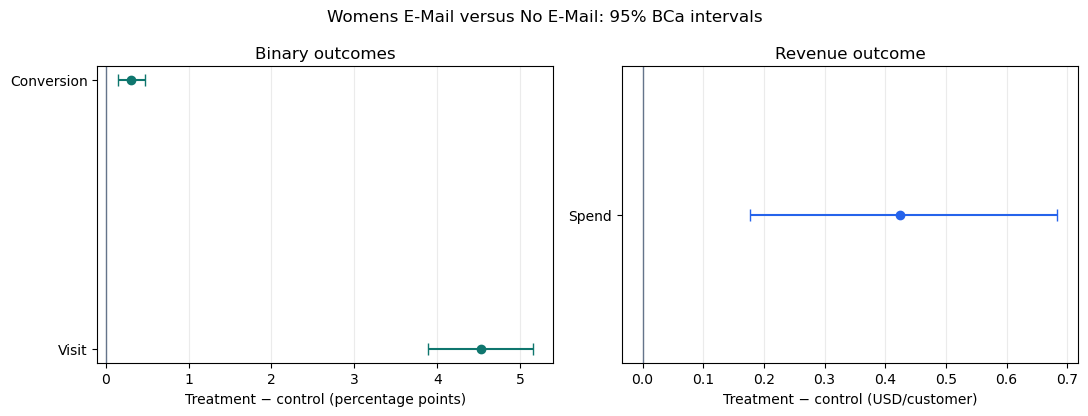

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4.2))

absolute = display_table.loc[rate_rows]
axes[0].errorbar(
    absolute["effect"],
    np.arange(len(absolute)),
    xerr=[absolute["effect"] - absolute["ci_low"], absolute["ci_high"] - absolute["effect"]],
    fmt="o",
    color="#0f766e",
    capsize=4,
)
axes[0].axvline(0, color="#64748b", linewidth=1)
axes[0].set_yticks(np.arange(len(absolute)), ["Visit", "Conversion"])
axes[0].set_xlabel("Treatment − control (percentage points)")
axes[0].set_title("Binary outcomes")
axes[0].grid(axis="x", alpha=0.25)

spend = display_table.loc["Spend per assigned customer"]
axes[1].errorbar(
    spend["effect"],
    0,
    xerr=[[spend["effect"] - spend["ci_low"]], [spend["ci_high"] - spend["effect"]]],
    fmt="o",
    color="#2563eb",
    capsize=4,
)
axes[1].axvline(0, color="#64748b", linewidth=1)
axes[1].set_yticks([0], ["Spend"])
axes[1].set_xlabel("Treatment − control (USD/customer)")
axes[1].set_title("Revenue outcome")
axes[1].grid(axis="x", alpha=0.25)

figure.suptitle("Womens E-Mail versus No E-Mail: 95% BCa intervals")
figure.tight_layout()
plt.show()

## Interpretation and boundaries

For this predefined contrast, the observed women's-email assignment increased the visit rate by about **4.52 percentage points**, conversion by **0.31 percentage points**, and spend by about **$0.42 per assigned customer**. All three absolute-effect intervals remain above zero in this sample. Relative conversion lift is about **54%**, but its interval is much wider than the absolute conversion interval because the control rate is low.

These are intention-to-treat estimates under the experiment's stated random assignment. They are not p-values, do not adjust for simultaneously selecting among both email campaigns, and do not establish that the same effect will generalize to another population or future campaign. The real dataset demonstrates an end-to-end workflow; synthetic simulations with known truth remain the appropriate way to assess confidence-interval coverage.